In [ ]:
%pip install textblob

In [ ]:
%pip install wordcloud

In [4]:
%pip install emoji



Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install pandas
%pip install matplotlib
%pip install seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

Importing the chat

In [27]:
file="Messages.txt"
with open(file,encoding='utf-8') as f:
    raw_chat=f.readlines()
print(raw_chat[:10])

['7/1/24, 9:03 AM - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. Learn more.\n', '7/1/24, 9:05 AM - Sumair Aziz⚡: Morning everyone! ☀️\n', '7/1/24, 9:12 AM - Ali Raza: Morning bro 😎\n', '7/1/24, 9:20 AM - Ayesha Ali: Good morning team!\n', '7/1/24, 9:29 AM - Fatima Gul: Let’s get our data science talk going 🤓\n', '7/1/24, 9:45 AM - Abrar Mustafa: Who’s ready to dive into some numbers 📊\n', '7/1/24, 10:02 AM - Ali Raza: Data science is literally taking over every field these days 🤓\n', '7/1/24, 10:07 AM - Ayesha Ali: Yeah but not everyone needs it honestly 😅\n', '7/1/24, 10:15 AM - Fatima Gul: True, but having basic knowledge helps a lot!\n', '7/1/24, 10:21 AM - Sumair Aziz⚡: I’m learning Python for data analysis 🐍\n']


Creating a dataframe

In [28]:
pattern = r'(\d{1,2}/\d{1,2}/\d{2}), (\d{1,2}:\d{2})\s?(AM|PM) - (.*?): (.*)'
data=[]
for line in raw_chat:
    match=re.match(pattern,line)
    if match:
        date,time,period,sender,message=match.groups()
        data.append([date,time,period,sender,message])
df=pd.DataFrame(data,columns=['Date','Time','Period','Sender','Message'])
df.head()

,Date,Time,Period,Sender,Message
0,7/1/24,9:05,AM,Sumair Aziz⚡,Morning everyone! ☀️
1,7/1/24,9:12,AM,Ali Raza,Morning bro 😎
2,7/1/24,9:20,AM,Ayesha Ali,Good morning team!
3,7/1/24,9:29,AM,Fatima Gul,Let’s get our data science talk going 🤓
4,7/1/24,9:45,AM,Abrar Mustafa,Who’s ready to dive into some numbers 📊


Total number of messages
Messages per sender (most active user)
Average words per message
Messages per day / per month trend
Visualization: Bar charts, line plots

In [29]:
# --- installs (run once if needed) ---
# pip install pandas matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dark mode setup
plt.style.use("dark_background")
sns.set_style("darkgrid")
plt.rcParams['axes.facecolor'] = "#222222"
plt.rcParams['figure.facecolor'] = "#111111"
plt.rcParams['savefig.facecolor'] = "#111111"
plt.rcParams['text.color'] = "white"
plt.rcParams['axes.labelcolor'] = "white"
plt.rcParams['xtick.color'] = "white"
plt.rcParams['ytick.color'] = "white"
plt.rcParams['font.family'] = 'DejaVu Sans'


In [30]:
# --- 1) Build Timestamp column ---
if 'Timestamp' not in df.columns:
    if {'Date', 'Time', 'Period'}.issubset(df.columns):
        ts = (
            df['Date'].astype(str).str.strip()
            + " " + df['Time'].astype(str).str.strip()
            + " " + df['Period'].astype(str).str.strip()
        )
        df['Timestamp'] = pd.to_datetime(ts, format='%m/%d/%y %I:%M %p', errors='coerce')
    else:
        ts = df['Date'].astype(str).str.strip() + " " + df['Time'].astype(str).str.strip()
        df['Timestamp'] = pd.to_datetime(ts, errors='coerce')

    if df['Timestamp'].isna().mean() > 0.2:
        df['Timestamp'] = pd.to_datetime(ts, dayfirst=True, errors='coerce')

In [31]:
# --- 2) Clean system messages ---
system_regex = (
    r'^(?:Messages and calls are end-to-end encrypted'
    r'|<Media omitted>'
    r'|is a contact'
    r'|added|left|changed the'
    r'|created group'
    r'|missed voice call|call was missed)'
)

mask_system = df['Message'].astype(str).str.contains(system_regex, case=False, na=False, regex=True)
mask_sender_missing = df['Sender'].isna() | df['Sender'].astype(str).str.strip().eq('')
df_clean = df[~(mask_system | mask_sender_missing)].copy()
df_clean['Message'] = df_clean['Message'].fillna('').astype(str)


In [32]:

# --- 3) Total number of messages ---
total_messages = len(df_clean)
print(f"Total messages (after filtering system msgs): {total_messages}")


Total messages (after filtering system msgs): 1767



Top senders by message count:
Sender
Fatima Gul       364
Sumair Aziz⚡     358
Ali Raza         354
Ayesha Ali       352
Abrar Mustafa    339
Name: count, dtype: int64


C:\Users\sumair\AppData\Local\Temp\ipykernel_6532\1955490153.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_senders, x='Sender', y='Messages', palette=["#FF1100", "#2F00FF"])
C:\Users\sumair\AppData\Local\Temp\ipykernel_6532\1955490153.py:11: UserWarning: 
The palette list has fewer values (2) than needed (5) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=top_senders, x='Sender', y='Messages', palette=["#FF1100", "#2F00FF"])


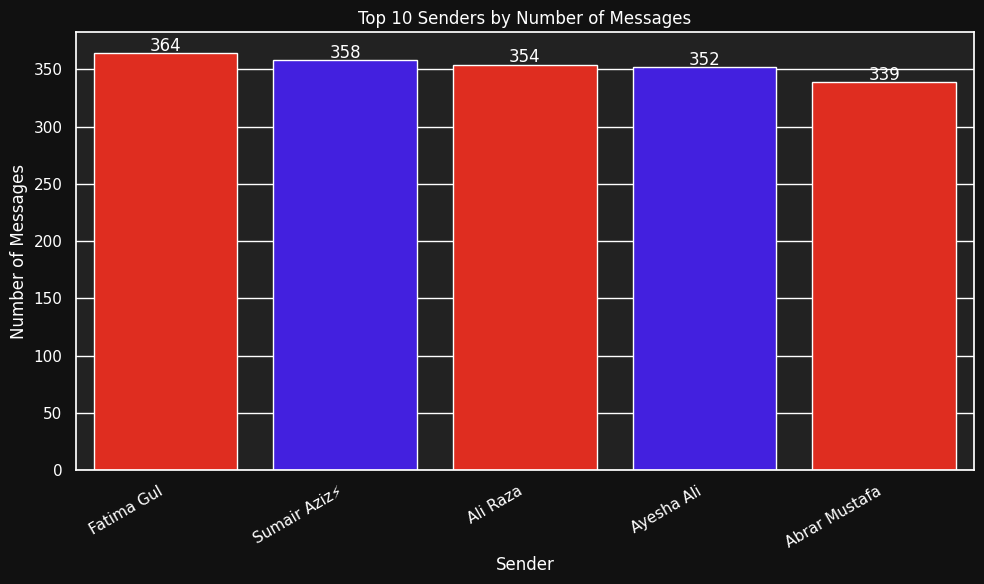

In [33]:
# --- 4) Messages per sender ---
msg_counts = df_clean['Sender'].value_counts()
print("\nTop senders by message count:")
print(msg_counts.head(10))

top_n = 10
top_senders = msg_counts.head(top_n).reset_index()
top_senders.columns = ['Sender','Messages']

plt.figure(figsize=(10,6))
ax = sns.barplot(data=top_senders, x='Sender', y='Messages', palette=["#FF1100", "#2F00FF"])

for i, v in enumerate(top_senders['Messages']):
    ax.text(i, v + 2, str(v), color='white', ha='center')

plt.title(f"Top {top_n} Senders by Number of Messages")
plt.xlabel("Sender")
plt.ylabel("Number of Messages")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()




Average words per message (overall): 5.02

Average words per message (top 10 senders):
Sender
Sumair Aziz⚡     5.466480
Ali Raza         4.988701
Ayesha Ali       4.960227
Abrar Mustafa    4.890855
Fatima Gul       4.777473
Name: Word_Count, dtype: float64


C:\Users\sumair\AppData\Local\Temp\ipykernel_6532\1539396413.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=avg_for_top, x='Sender', y='AvgWords', palette="Greens_d")


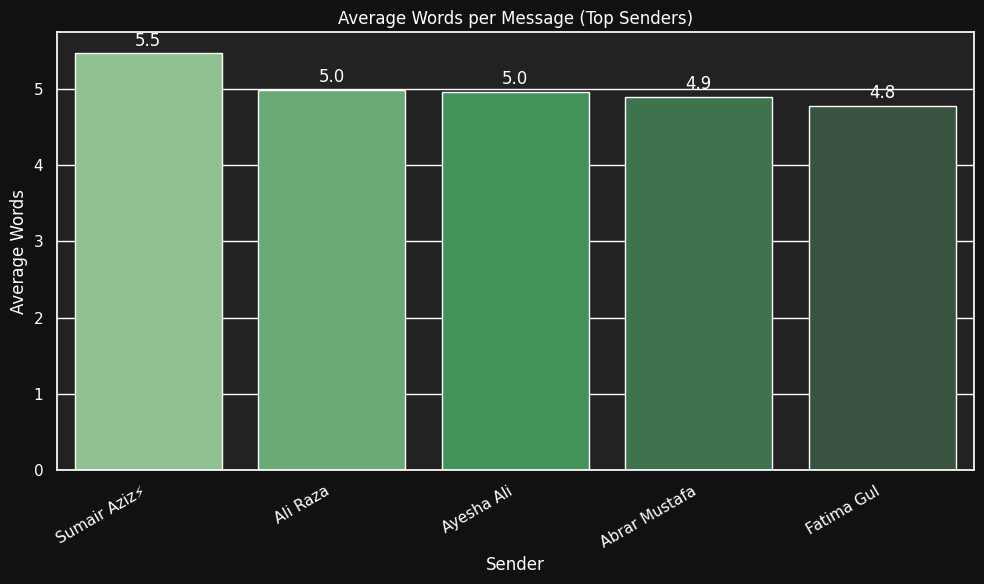

In [34]:

# --- 5) Average words per message ---
df_clean['Word_Count'] = df_clean['Message'].str.split().apply(lambda x: len(x) if isinstance(x, list) else 0)

avg_words_overall = df_clean['Word_Count'].mean()
print(f"\nAverage words per message (overall): {avg_words_overall:.2f}")

avg_words_by_sender = df_clean.groupby('Sender')['Word_Count'].mean().sort_values(ascending=False)
print("\nAverage words per message (top 10 senders):")
print(avg_words_by_sender.head(10))

top_senders_list = top_senders['Sender'].tolist()
avg_for_top = avg_words_by_sender.loc[avg_words_by_sender.index.isin(top_senders_list)].reset_index()
avg_for_top.columns = ['Sender','AvgWords']

plt.figure(figsize=(10,6))
ax = sns.barplot(data=avg_for_top, x='Sender', y='AvgWords', palette="Greens_d")

for i, v in enumerate(avg_for_top['AvgWords']):
    ax.text(i, v + 0.1, f"{v:.1f}", color='white', ha='center')

plt.title("Average Words per Message (Top Senders)")
plt.xlabel("Sender")
plt.ylabel("Average Words")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


C:\Users\sumair\AppData\Local\Temp\ipykernel_6532\2018627105.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df_time['Message'].resample('M').count()


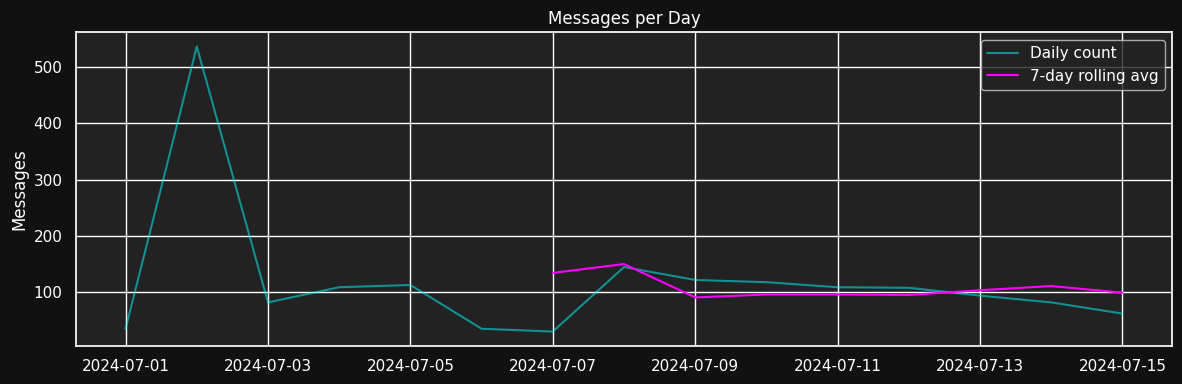

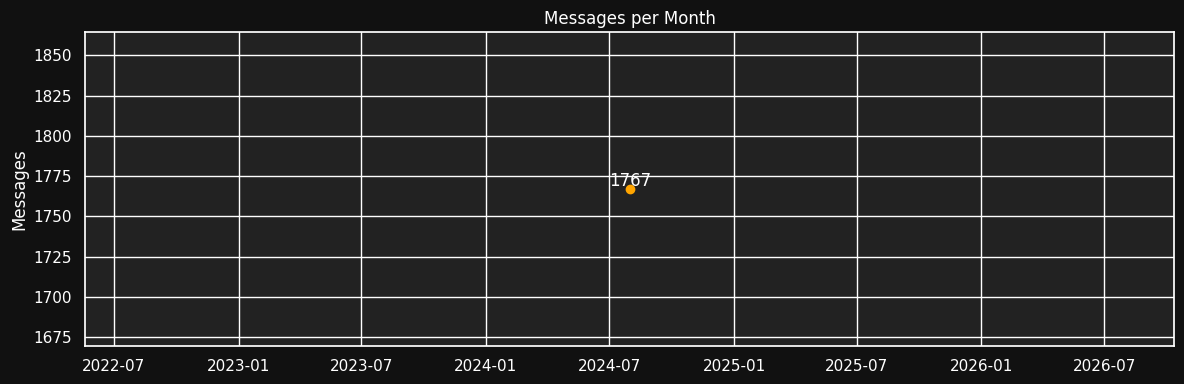

In [35]:
# --- 6) Messages per day / month trend ---
df_time = df_clean.set_index('Timestamp').sort_index()
daily = df_time['Message'].resample('D').count()
monthly = df_time['Message'].resample('M').count()

plt.figure(figsize=(12,4))
plt.plot(daily.index, daily.values, alpha=0.5, label='Daily count', color='cyan')
plt.plot(daily.index, daily.rolling(7).mean(), label='7-day rolling avg', color='magenta')
plt.title('Messages per Day')
plt.ylabel('Messages')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(monthly.index, monthly.values, marker='o', color='orange')

for x, y in zip(monthly.index, monthly.values):
    plt.text(x, y+2, str(y), ha='center', color='white')

plt.title('Messages per Month')
plt.ylabel('Messages')
plt.tight_layout()
plt.show()


In [36]:

# --- 7) Summary dictionary ---
summary_stats = {
    'total_messages': total_messages,
    'messages_per_sender': msg_counts,
    'avg_words_overall': avg_words_overall,
    'avg_words_by_sender': avg_words_by_sender,
    'daily_counts': daily,
    'monthly_counts': monthly
}
plt.style.use("dark_background")
sns.set_theme(style="whitegrid")

In [37]:


# 8 Extracting useful time features
df_clean['Hour']=df_clean['Timestamp'].dt.hour
df_clean['DayOfWeek']=df_clean['Timestamp'].dt.day_name()
df_clean['Month']=df_clean["Timestamp"].dt.to_period('M')




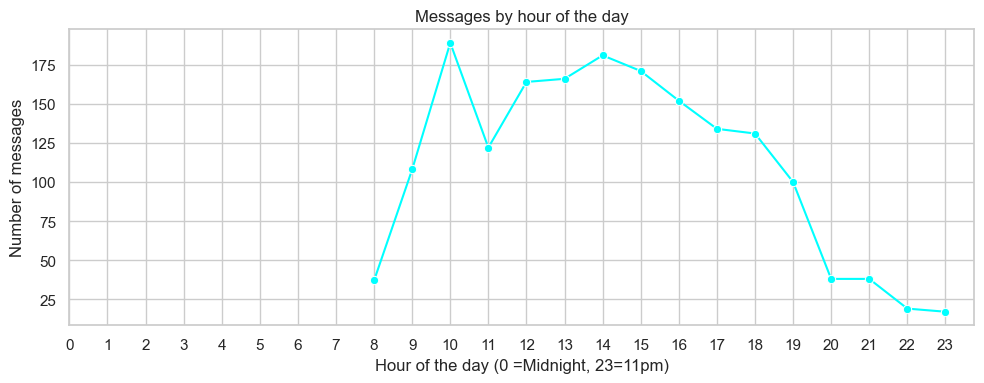

In [38]:

# 9 Message by Hour of the day
hourly = df_clean.groupby('Hour').size()

plt.figure(figsize=(10,4))
sns.lineplot(x=hourly.index,y=hourly.values,marker='o',color="cyan")
plt.title("Messages by hour of the day")
plt.xlabel("Hour of the day (0 =Midnight, 23=11pm)")
plt.ylabel("Number of messages")
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()



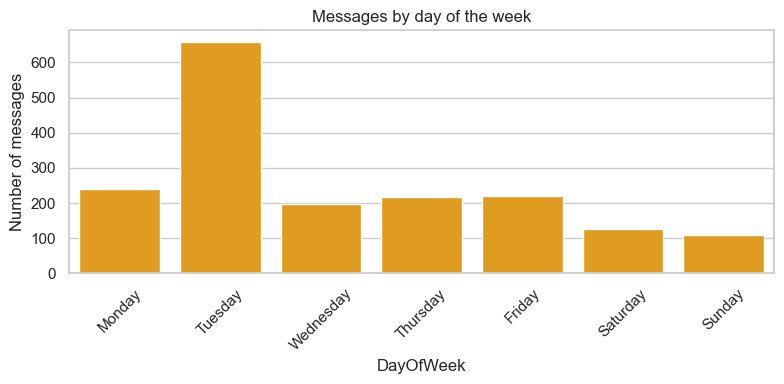

In [39]:

# 10 Message by day of the week
dow=df_clean.groupby('DayOfWeek').size()
# 11 eorder days properly
dow=dow.reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.figure(figsize=(8,4))
sns.barplot(x=dow.index,y=dow.values,color="orange")
plt.title("Messages by day of the week")
plt.ylabel("Number of messages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


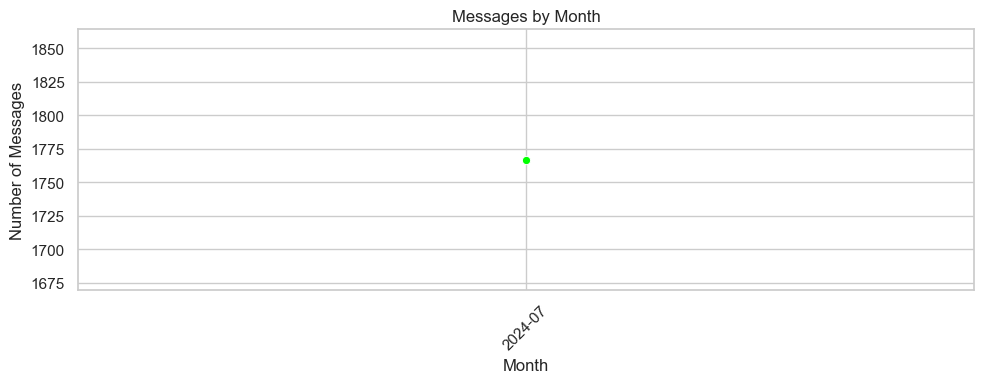

In [40]:
# 12) Messages by Month
# ---------------------------
monthly = df_clean.groupby('Month').size()

plt.figure(figsize=(10,4))
sns.lineplot(x=monthly.index.astype(str), y=monthly.values, marker="o", color="lime")
plt.title("Messages by Month")
plt.ylabel("Number of Messages")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


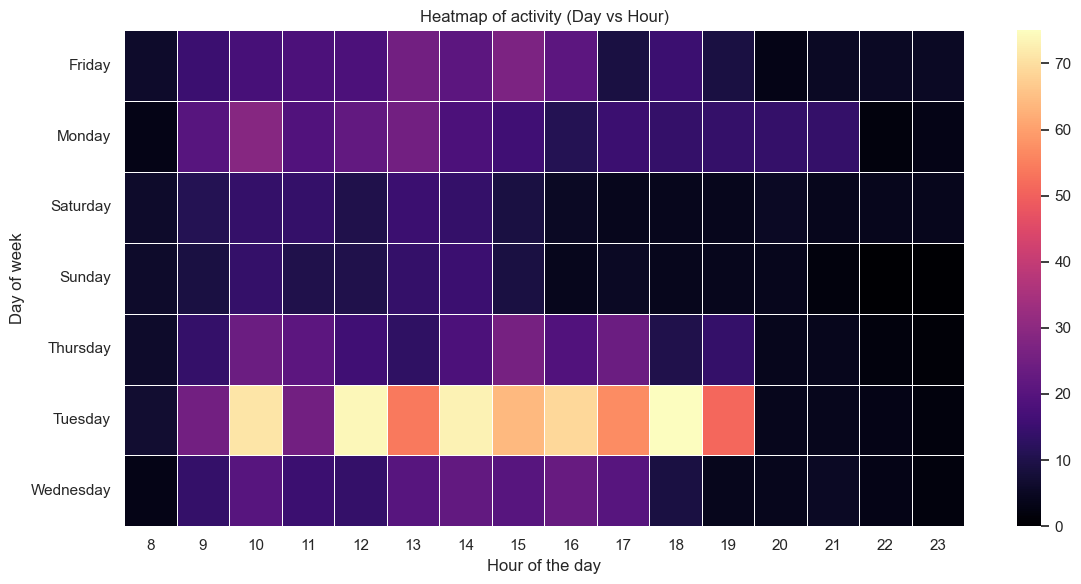

In [41]:
# ---------------------------
# 13) Heatmap: Activity by Hour & Day
# ---------------------------
heatmap_data = df_clean.groupby(['DayOfWeek','Hour']).size().unstack(fill_value=0)
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data,cmap="magma",linewidths=.5)
plt.title("Heatmap of activity (Day vs Hour)")
plt.xlabel("Hour of the day")
plt.ylabel("Day of week")
plt.tight_layout()
plt.show()

In [42]:
import re
from collections import Counter
from wordcloud import WordCloud
import emoji

plt.style.use("dark_background")

# --- 14) Prepare text data ---
# Remove links, media messages, system msgs (already filtered in df_clean)
df_clean['Cleaned'] = df_clean['Message'].str.replace(r'http\S+|www\S+', '', regex=True)





In [43]:
# --- 15) Top words per user ---
def get_top_words(messages, n=10):
    words = " ".join(messages).lower().split()
    # filter small stop words (you can expand this list)
    stopwords = {"the","is","to","and","of","a","in","i","you","me","it","for","on","that","this","bhi","raha","ker","hua","huwa","hain"}
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

print("\nTop words for each sender:")
for sender, msgs in df_clean.groupby("Sender")['Cleaned']:
    print(f"\n{sender}:")
    print(get_top_words(msgs, n=10))



Top words for each sender:

Abrar Mustafa:
[("i'll", 47), ('our', 16), ('are', 15), ('model', 13), ('data', 11), ('project', 10), ("it's", 10), ('morning!', 10), ('same', 9), ('but', 9)]

Ali Raza:
[("i'll", 26), ("let's", 17), ('model', 15), ('data', 14), ('should', 13), ('with', 13), ("i'm", 13), ('ready', 12), ('great', 11), ('our', 11)]

Ayesha Ali:
[("i'll", 35), ('good', 22), ('but', 14), ('morning', 13), ('team', 13), ('data', 12), ('morning!', 12), ('are', 12), ("that's", 12), ('some', 12)]

Fatima Gul:
[("i'll", 40), ('are', 16), ('with', 14), ('same', 13), ('morning', 12), ('good', 11), ('morning!', 11), ('okay', 10), ('design', 10), ('our', 9)]

Sumair Aziz⚡:
[("let's", 102), ('great!', 37), ('perfect!', 34), ('our', 25), ('start', 20), ('morning', 19), ('data', 19), ('all', 16), ('see', 15), ('team!', 14)]


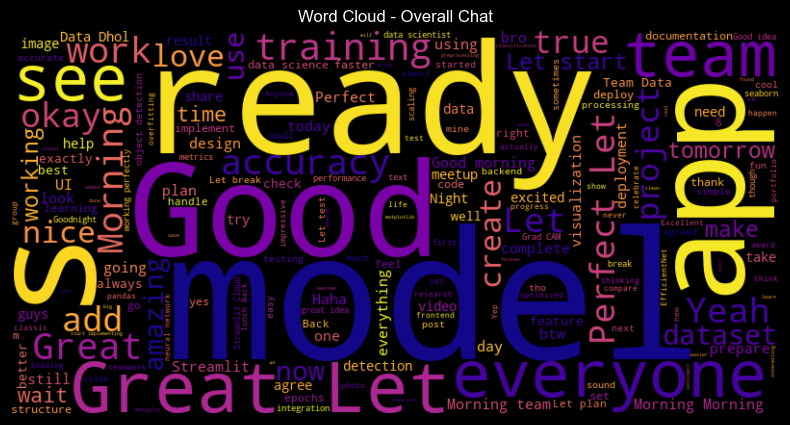

In [44]:

# --- 16) Word Cloud (overall) ---
all_text = " ".join(df_clean['Cleaned'])
wordcloud = WordCloud(width=800, height=400, background_color="black", colormap="plasma").generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Overall Chat")
plt.show()


Top Emojis: [('😂', 185), ('😭', 92), ('😎', 74), ('😅', 66), ('🔥', 31), ('💪', 30), ('☕', 30), ('😍', 27), ('💀', 27), ('😩', 23)]


C:\Users\sumair\AppData\Local\Temp\ipykernel_6532\1037088361.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=emojis, y=counts, hue=None, palette="magma", legend=False)


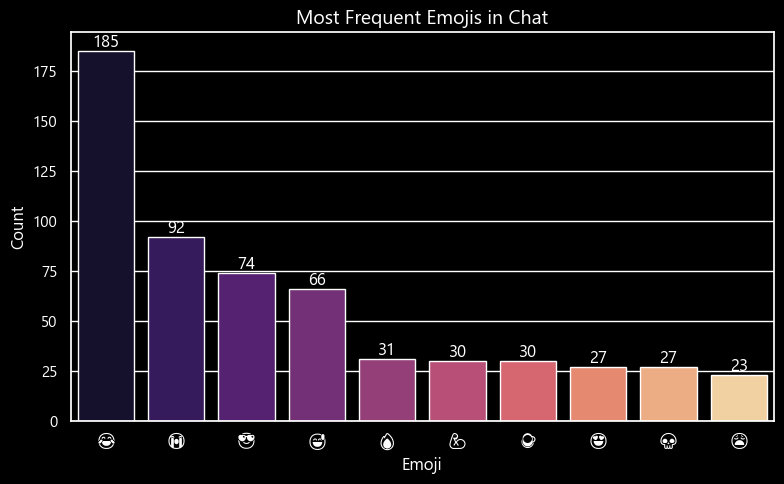

In [45]:
# --- 17) Emoji extraction ---

# --- 1) Function to extract emojis from a string ---
def extract_emojis(s):
    return [d['emoji'] for d in emoji.emoji_list(s)]

# --- 2) Apply to full DataFrame ---
df_clean['Emojis'] = df_clean['Message'].apply(extract_emojis)

# Flatten the list of lists into one big list
all_emojis = [e for sublist in df_clean['Emojis'] for e in sublist]

# --- 3) Count frequency ---
emoji_counts = Counter(all_emojis)

# Get top 10 (or 3 if you prefer)
top_emojis = emoji_counts.most_common(10)
print("Top Emojis:", top_emojis)

emojis = [e for e, _ in top_emojis]
counts = [c for _, c in top_emojis]

# --- 4) Fix font issue (so emojis show up) ---
plt.rcParams['font.family'] = 'Segoe UI Emoji'  # Windows
# macOS -> 'Apple Color Emoji'
# Linux -> 'Noto Color Emoji'

# --- 5) Plot bar chart ---
plt.figure(figsize=(8,5))
ax = sns.barplot(x=emojis, y=counts, hue=None, palette="magma", legend=False)
for i in ax.containers:
    ax.bar_label(i)
plt.title("Most Frequent Emojis in Chat", fontsize=14)
plt.xlabel("Emoji", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
%pip install vadersentiment

Emoji sentiments

In [46]:
emoji_sentiment = {
    "😂": "Positive", "🤣": "Positive", "😁": "Positive", "😍": "Positive", "🥰": "Positive", "❤️": "Positive", "👍": "Positive",
    "😭": "Negative", "😡": "Negative", "💔": "Negative", "👎": "Negative",
    "😐": "Neutral", "🙂": "Neutral", "🙃": "Neutral", "🤔": "Neutral"
}


Applying sentiment to my chat

In [47]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def get_combined_sentiment(text):
    # 1) Get text sentiment
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        text_sent = "Positive"
    elif score <= -0.05:
        text_sent = "Negative"
    else:
        text_sent = "Neutral"
    
    # 2) Extract emojis
    emojis_in_text = [d['emoji'] for d in emoji.emoji_list(str(text))]
    
    # 3) Count emoji sentiment
    emoji_labels = []
    for e in emojis_in_text:
        if e in emoji_sentiment:
            emoji_labels.append(emoji_sentiment[e])
    
    # 4) Combine (majority wins, otherwise fall back to text sentiment)
    if emoji_labels:
        # Pick the majority sentiment from emojis
        counts = Counter(emoji_labels)
        emoji_sent = counts.most_common(1)[0][0]
        
        # If emoji sentiment contradicts text, give more weight to emojis
        if emoji_sent != text_sent:
            return emoji_sent
    return text_sent

df_clean['Sentiment'] = df_clean['Message'].apply(get_combined_sentiment)


Sentiment Breakdown

C:\Users\sumair\AppData\Local\Temp\ipykernel_6532\3602190164.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Sentiment", data=df_clean, order=["Positive","Neutral","Negative"], palette="coolwarm")


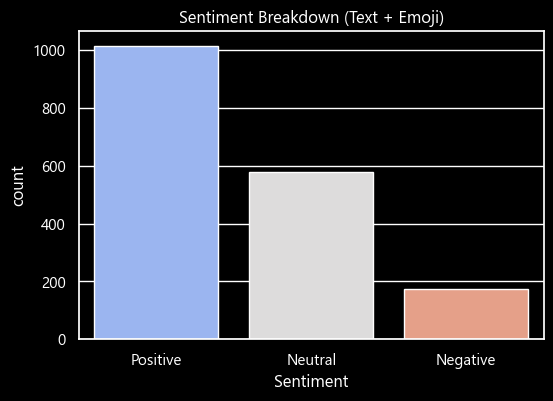

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sentiment", data=df_clean, order=["Positive","Neutral","Negative"], palette="coolwarm")
plt.title("Sentiment Breakdown (Text + Emoji)")
plt.show()


Sentiment Trend over time

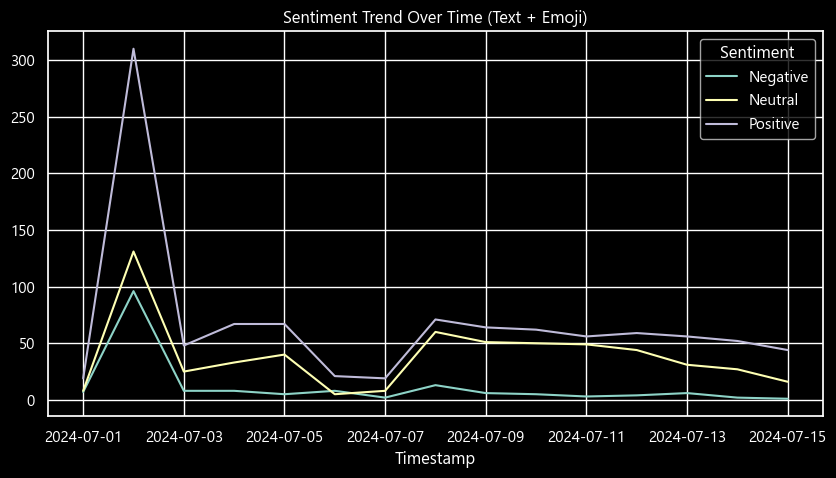

In [49]:
df_clean['Timestamp']=pd.to_datetime(df_clean['Timestamp'])

sentiment_trend = df_clean.groupby([df_clean['Timestamp'].dt.date, 'Sentiment']).size().unstack().fillna(0)
sentiment_trend.plot(figsize=(10,5))
plt.title("Sentiment Trend Over Time (Text + Emoji)")
plt.show()


Compare Sentiment between users

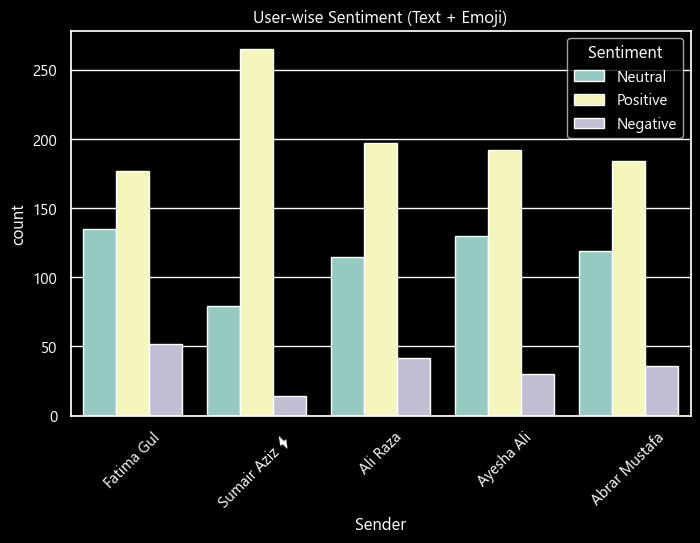

In [50]:
plt.figure(figsize=(8,5))
sns.countplot(x="Sender", hue="Sentiment", data=df_clean, order=df_clean['Sender'].value_counts().index)
plt.title("User-wise Sentiment (Text + Emoji)")
plt.xticks(rotation=45)
plt.show()

In [51]:
df_clean.to_csv("Messages.csv", index=False)
